### **PART 1 - CONNECTING TO LASTFM API AND BRINGING IN NECESSARY DATA, PUTTING INTO POLISHED DATAFRAMES** ###

In [84]:
from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.getenv('LASTFM_API_KEY')

In [85]:
import requests
import pandas as pd
import json
from sklearn.cluster import KMeans

In [86]:
url = "http://ws.audioscrobbler.com/2.0/"

In [87]:
#Checking what this API end-point returns using Coldplay as an example.
#Our end goal is to create an artist recommendation system that is similar/better

params_similar_artists = {
    "method":"artist.getSimilar",
    "limit": 5,
    "artist": "Coldplay",
    "format":"json",
    "autocorrect": 1,
    "api_key": api_key
}

response = requests.get(url, params_similar_artists)

data_similar_artists = response.json()

data_similar_artists

{'similarartists': {'artist': [{'name': 'Keane',
    'mbid': 'c7020c6d-cae9-4db3-92a7-e5c561cbad50',
    'match': '1',
    'url': 'https://www.last.fm/music/Keane',
    'image': [{'#text': 'https://lastfm.freetls.fastly.net/i/u/34s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'small'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/64s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'medium'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/174s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'large'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/300x300/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'extralarge'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/300x300/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'mega'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/300x300/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': ''}],
    'streamable': '0'},
   {'name': 'OneRepublic',
    'mbid': 'c33c2065-b1c3-4406-b06

In [88]:
#Looking at tracks end-point just to get an idea of what the structure of the JSON data looks like

params_tracks = {
    "method": "chart.getTopTracks",
    "api_key": api_key,
    "format":"json",
    "limit": 10
}

response = requests.get(url, params_tracks)

data_tracks = response.json()

data_tracks

{'tracks': {'track': [{'name': 'the cure',
    'duration': '297',
    'playcount': '10040156',
    'listeners': '719802',
    'mbid': '0f0097d9-5e12-4c76-8fbb-3409641c0bb4',
    'url': 'https://www.last.fm/music/Olivia+Rodrigo/_/the+cure',
    'streamable': {'#text': '0', 'fulltrack': '0'},
    'artist': {'name': 'Olivia Rodrigo',
     'mbid': '6925db17-f35e-42f3-a4eb-84ee6bf5d4b0',
     'url': 'https://www.last.fm/music/Olivia+Rodrigo'},
    'image': [{'#text': 'https://lastfm.freetls.fastly.net/i/u/34s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'small'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/64s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'medium'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/174s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'large'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/300x300/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'extralarge'}]},
   {'name': 'stupid song',
    'duration': '209',
 

In [ ]:
#Getting the top 1000 artists on the website by playcount. Limiting our code to the 1000 most popular artists only 

params = {
    "method": "chart.gettopartists",
    "api_key": api_key,
    "format": "json",
    "limit": 1000
}

response = requests.get(url, params=params)
data = response.json()

print(data)

In [ ]:
#Readable human format so we can understand the JSON format better
print(json.dumps(data['artists']['artist'][0], indent=4))

In [90]:
#Ensuring it is returning 1000 artists and not a different number

print(len(data['artists']['artist']))

1000


In [91]:
#Creating the df_artists and cleaning it so we keep the relevant columns and drop anything we don't need

df = pd.json_normalize(data['artists']['artist'])

df_artists = df[['name', 'playcount', 'listeners', 'url', 'streamable']]

df_artists

,name,playcount,listeners,url,streamable
0,Olivia Rodrigo,647494364,3253045,https://www.last.fm/music/Olivia+Rodrigo,0
1,Ariana Grande,1170388457,4591268,https://www.last.fm/music/Ariana+Grande,0
2,The Weeknd,1154188450,5417976,https://www.last.fm/music/The+Weeknd,0
3,Kanye West,1583858391,8041281,https://www.last.fm/music/Kanye+West,0
4,Drake,1241490432,6831274,https://www.last.fm/music/Drake,0
...,...,...,...,...,...
995,Leith Ross,29634058,840140,https://www.last.fm/music/Leith+Ross,0
996,Lyn,29150159,552811,https://www.last.fm/music/Lyn,0
997,Glee Cast,232302737,1910476,https://www.last.fm/music/Glee+Cast,0
998,K'naan,14797897,1194808,https://www.last.fm/music/K%27naan,0


In [92]:
#Creating a list of tags for each artist from the getTopTags end-point that we will later use to cluster artists

rows = []

for artist in df_artists['name']:

    params = {
        "method": "artist.getTopTags",
        "api_key": api_key,
        "format": "json",
        "artist": artist,
        "autocorrect": 1
    }

    response = requests.get(url, params=params)
    data_tags = response.json()

    tags = data_tags.get("toptags", {}).get("tag", [])

    if isinstance(tags, dict):
        tags = [tags]

    for t in tags:
        rows.append({
            "artist": artist,
            "tag": t["name"],
            "count": int(t["count"])
        })


In [ ]:
#Understanding the structure of the tags JSON

print(json.dumps(data_tags['toptags']['tag'], indent=4))

In [93]:
#Creating a dataframe with each row having a tag per artist that we can then pivot to create a final tags table

df_tags = pd.DataFrame(rows)

df_tags

,artist,tag,count
0,Olivia Rodrigo,pop,100
1,Olivia Rodrigo,pop rock,74
2,Olivia Rodrigo,indie pop,19
3,Olivia Rodrigo,rock,19
4,Olivia Rodrigo,female vocalists,9
...,...,...,...
9897,Creepy Nuts,hip hop,3
9898,Creepy Nuts,pop,3
9899,Creepy Nuts,yakousei,1
9900,Creepy Nuts,Asian,1


In [94]:
df_tags.shape

(9902, 3)

In [95]:
#1464 unique tags for just 1000 artists is fairly high, we can later filter these to take the more common tags

df_tags['tag'].nunique()

1468

In [96]:
#Taking the 60 most commonly occuring tags and creating a df of those to use later

df_final_tags = df_tags['tag'].value_counts().head(60).to_frame()

df_final_tags.reset_index(inplace=True)

df_final_tags.drop(columns=['count'], inplace=True)

df_final_tags

,tag
0,pop
1,american
2,rock
3,indie
4,Hip-Hop
5,alternative
6,female vocalists
7,hip hop
8,rap
9,electronic


In [97]:
#filtering the earlier df we made to include only the 60 tags from above

df_tags = df_tags[df_tags['tag'].isin(df_final_tags['tag'])]

df_tags.reset_index(inplace = True)

df_tags

,index,artist,tag,count
0,0,Olivia Rodrigo,pop,100
1,1,Olivia Rodrigo,pop rock,74
2,2,Olivia Rodrigo,indie pop,19
3,3,Olivia Rodrigo,rock,19
4,4,Olivia Rodrigo,female vocalists,9
...,...,...,...,...
6214,9891,K'naan,male vocalists,1
6215,9894,Creepy Nuts,Hip-Hop,34
6216,9897,Creepy Nuts,hip hop,3
6217,9898,Creepy Nuts,pop,3


In [98]:
#Pivoting so that each tag is a column and each index (i.e. unique row) is an artist

df_artist_tags = df_tags.pivot_table(index='artist', columns='tag', values='count', aggfunc='sum', fill_value=0)

pd.set_option('display.max_columns', None)

df_artist_tags

tag,70s,80s,90s,Canadian,Gangsta Rap,Hip-Hop,House,Korean,Kpop,Lo-Fi,USA,United States,acoustic,alternative,alternative metal,alternative rnb,alternative rock,american,bedroom pop,british,classic rock,cloud rap,dance,dream pop,electronic,electronica,electropop,emo,experimental,female vocalists,folk,funk,hard rock,hip hop,indie,indie pop,indie rock,jazz,k-pop,latin,male vocalists,metal,my top songs,new wave,pop,pop punk,pop rap,pop rock,post-punk,psychedelic,punk,r&b,rap,rnb,rock,shoegaze,singer-songwriter,soul,synthpop,trap
artist,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
$uicideboy$,0,0,0,0,0,77,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,100,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,35,0,0,0,0,0,0,39
*NSYNC,0,0,33,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0,0,26,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,100,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
100 gecs,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,2,0,0,0,0,0,0,38,0,2,0,33,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10cc,38,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33,100,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,15,0,0,0,0,0,0,0,0,0,67,0,0,0,0,0
21 Savage,0,0,0,0,1,98,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,61,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,64,0,0,0,0,0,0,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
wifiskeleton,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,44,0,0,0,0,0,0,0,0,17,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
will.i.am,0,0,0,0,0,100,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0,0,1,0,1,0,0,0,0,0,0,36,0,13,0,0,0,0,0,0,1,0,0,0,8,0,0,0,0,0,0,0,67,42,0,0,0,0,0,0
xaviersobased,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,29,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2


In [99]:
#From the API's artist.getSimilar we already know that these artists were grouped together
#Let's see what their tags look like in our df

pd.set_option('display.max_columns', None)

df_artist_tags.loc[['Keane','OneRepublic','Coldplay']]

tag,70s,80s,90s,Canadian,Gangsta Rap,Hip-Hop,House,Korean,Kpop,Lo-Fi,USA,United States,acoustic,alternative,alternative metal,alternative rnb,alternative rock,american,bedroom pop,british,classic rock,cloud rap,dance,dream pop,electronic,electronica,electropop,emo,experimental,female vocalists,folk,funk,hard rock,hip hop,indie,indie pop,indie rock,jazz,k-pop,latin,male vocalists,metal,my top songs,new wave,pop,pop punk,pop rap,pop rock,post-punk,psychedelic,punk,r&b,rap,rnb,rock,shoegaze,singer-songwriter,soul,synthpop,trap
artist,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Keane,0,0,0,0,0,0,0,0,0,0,0,0,0,46,0,0,5,0,0,49,0,0,0,0,0,0,0,0,0,0,0,0,0,0,86,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,21,0,0,0,0,0
OneRepublic,0,0,0,0,0,0,0,0,0,0,0,0,0,61,0,0,53,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,20,0,0,0,0,0,1,0,0,0,7,0,0,100,0,0,0,0,0,0,100,0,0,0,0,0
Coldplay,0,0,0,0,0,0,0,0,0,0,0,0,0,93,0,0,56,0,0,11,0,0,0,0,0,0,0,0,0,0,0,0,0,0,21,0,1,0,0,0,0,0,0,0,4,0,0,1,0,0,0,0,0,0,100,0,0,0,0,0


In [100]:
#Normalising the data so that higher number of tags don't dominate the model but the ratio between number of tags is maintained

from sklearn.preprocessing import normalize

df_artist_tags_norm = normalize(df_artist_tags, norm='l2')

df_artist_tags_norm

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.28535652],
       [0.        , 0.        , 0.30371242, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.06880209],
       [0.        , 0.        , 0.        , ..., 0.        , 0.25428735,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.07581416]])

In [101]:
df_artist_tags_norm.shape

(993, 60)

In [102]:
#Ensuring the df_artists dataframe we created earlier is filtered to only the ones who have our post-filtering tags

df_artists = df_artists[df_artists['name'].isin(df_artist_tags.index)]

### **PART 2 - CREATING THE CLUSTERS FOR ARTISTS THAT WILL BE USED TO RECOMMEND SIMILAR ARTISTS** ###

In [103]:
#Before we run the actual code, how many clusters should be create?

inertias = []
k_range = range(1, 31)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df_artist_tags_norm)
    inertias.append(km.inertia_)

/Users/rohanwadhawan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/rohanwadhawan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/rohanwadhawan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/rohanwadhawan/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/rohanwadhawan/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/rohanwadhawan/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value enco

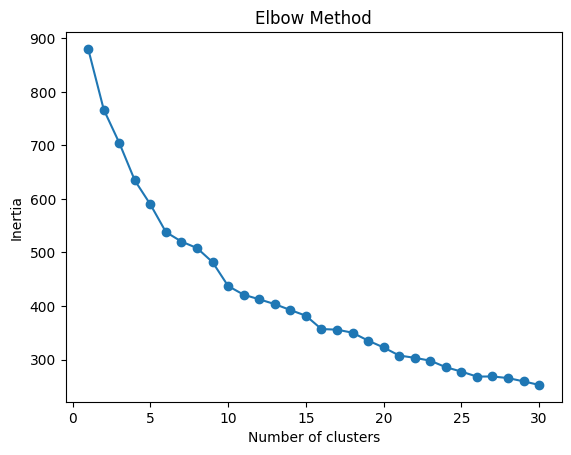

In [104]:
#Lowest intertia around 30 clusters, so we can go with that
#We did try with 20 clusters earlier but didn't get great results (very different artists in the same cluster)

import matplotlib.pyplot as plt

plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [105]:
#Running the code to create the actual cluster based on elbow method above

kmeans = KMeans(n_clusters=30, random_state=42)
kmeans.fit(df_artist_tags_norm)

/Users/rohanwadhawan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/rohanwadhawan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/rohanwadhawan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/rohanwadhawan/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/rohanwadhawan/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/rohanwadhawan/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value enco

KMeans(n_clusters=30, random_state=42)

In [106]:
df_artists['cluster'] = kmeans.labels_

/var/folders/1r/79bn_tkx32b4g0_bpxxdz_gr0000gn/T/ipykernel_92212/1873881759.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_artists['cluster'] = kmeans.labels_


In [107]:
#Just checking which artists are in cluster 0

df_artists[df_artists['cluster'] == 0]['name'].values

array(['TV Girl', 'Black Eyed Peas', 'Oasis', 'Megan Thee Stallion',
       'Troye Sivan', 'Prince', 'Big Thief', 'Current Joys',
       'Kylie Minogue', 'Gucci Mane', 'Jason Derulo', 'Fetty Wap',
       'Pantera', 'Givēon', 'Superheaven', 'mgk', 'M.I.A.', 'Lloyd',
       'Disturbed', 'Basement', 'Feng', 'Young Nudy', 'Lizzo',
       'Bo Burnham'], dtype=object)

In [108]:
#Checking if there are artists with many 'blank' columns out of a total of 60.
#Seems like there are many artists with upto 59 'blank' tags/no tags from our list which makes clustering them hard

(df_artist_tags == 0).sum(axis=1).sort_values(ascending=False).head(20)

artist
Azumi Takahashi    59
S3RL               59
Steven Universe    59
Marina Sena        59
Fuerza Regida      59
Machine Girl       59
Gojira             59
LONOWN             59
Jorge Ben Jor      59
Kikuo              59
C418               59
NandaTsunami       59
Feid               59
Kygo               58
Toby Fox           58
alex_g_offline     58
Pantera            58
Ozuna              58
Niki               58
Chris Stapleton    58
dtype: int64

In [109]:
#Checking how many artists correspond to the number of tags. For example, 12 artists have only 1 tag etc.

tag_counts = (df_artist_tags > 0).sum(axis=1)
print(tag_counts.value_counts().sort_index())

1      13
2      21
3      52
4      99
5     145
6     184
7     206
8     149
9      93
10     31
Name: count, dtype: int64


In [110]:
#filtering the artists even further to only get those who have at least 5 tags

artists_to_keep = tag_counts[tag_counts >=5].index

df_artist_tags = df_artist_tags.loc[artists_to_keep]

df_artist_tags

tag,70s,80s,90s,Canadian,Gangsta Rap,Hip-Hop,House,Korean,Kpop,Lo-Fi,USA,United States,acoustic,alternative,alternative metal,alternative rnb,alternative rock,american,bedroom pop,british,classic rock,cloud rap,dance,dream pop,electronic,electronica,electropop,emo,experimental,female vocalists,folk,funk,hard rock,hip hop,indie,indie pop,indie rock,jazz,k-pop,latin,male vocalists,metal,my top songs,new wave,pop,pop punk,pop rap,pop rock,post-punk,psychedelic,punk,r&b,rap,rnb,rock,shoegaze,singer-songwriter,soul,synthpop,trap
artist,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
$uicideboy$,0,0,0,0,0,77,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,100,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,35,0,0,0,0,0,0,39
*NSYNC,0,0,33,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0,0,26,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,100,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
100 gecs,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,2,0,0,0,0,0,0,38,0,2,0,33,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10cc,38,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33,100,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,15,0,0,0,0,0,0,0,0,0,67,0,0,0,0,0
21 Savage,0,0,0,0,1,98,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,61,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,64,0,0,0,0,0,0,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
t.A.T.u.,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,14,0,38,0,1,0,0,37,0,0,0,0,0,0,0,0,0,0,0,0,0,0,100,0,0,2,0,0,0,0,0,0,2,0,0,0,0,0
underscores,0,0,0,0,0,0,0,0,0,0,0,6,0,0,0,0,0,0,0,0,0,0,0,0,37,0,1,0,0,0,0,0,0,0,1,64,16,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
wave to earth,0,0,0,0,0,0,0,100,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,100,29,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,4,0,0


In [111]:
#normalizing the new df, which is filtered down to 810 artists

df_artist_tags_norm = normalize(df_artist_tags, norm='l2')

df_artist_tags_norm

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.28535652],
       [0.        , 0.        , 0.30371242, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.02769576, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.07581416]])

In [112]:
#Creating the new clusters (30) 

kmeans = KMeans(n_clusters=30, random_state=42)
kmeans.fit(df_artist_tags_norm)

/Users/rohanwadhawan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/rohanwadhawan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/rohanwadhawan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


KMeans(n_clusters=30, random_state=42)

In [113]:
df_artists_filtered = df_artists[df_artists['name'].isin(df_artist_tags.index)]
df_artists_filtered = df_artists_filtered.reset_index(drop=True)
df_artists_filtered['cluster'] = kmeans.labels_

In [114]:
df_artists_filtered[df_artists_filtered['cluster'] == 0]['name'].values

array(['A Boogie wit da Hoodie', 'Thundercat', 'Artemas', 'wave to earth',
       'Eve', 'Ava Max', 'Young the Giant', 'The Kooks'], dtype=object)

In [115]:
#Checking what a few clusters look like

for i in range(5):
    print(f"Cluster {i}:")
    print(df_artists_filtered[df_artists_filtered['cluster'] == i]['name'].values)
    print()

Cluster 0:
['A Boogie wit da Hoodie' 'Thundercat' 'Artemas' 'wave to earth' 'Eve'
 'Ava Max' 'Young the Giant' 'The Kooks']

Cluster 1:
['Gorillaz' 'Don Toliver' 'Post Malone' 'Panic! at the Disco'
 'The Smashing Pumpkins' 'Miley Cyrus' 'Elton John' 'ILLIT' 'OutKast'
 'Kid Cudi' 'Usher' 'Cage the Elephant' 'Flo Rida' 'Gigi Perez'
 'Massive Attack' 'Jamiroquai' 'Elliott Smith' 'New Order' 'P!nk'
 'Jhené Aiko' 'Labrinth' 'Benson Boone' 'Portishead' 'Bon Iver'
 'Matt Maltese' 'King Von' 'Royel Otis' 'Mumford & Sons' 'Balu Brigada'
 'Rick Ross' 'Peter, Paul and Mary' 'NCT 127' 'Jonas Brothers'
 'Wolf Parade' 'The Front Bottoms' 'Passion Pit' 'Remi Wolf'
 'Miracle Musical' 'Mustard' 'Rina Sawayama' 'The Who' 'King Gnu' 'Kelela'
 'Heart']

Cluster 2:
['SZA' 'Mitski' 'The Beatles' 'Calvin Harris' 'Queen' 'System of a Down'
 'Metallica' 'Evanescence' 'Chris Brown' 'Trippie Redd' 'Lil Tecca'
 'Wallows' 'Sam Smith' 'Hotel Ugly' 'Nickelback' 'Audioslave' 'Frou Frou'
 'Joy Division' 'HIM' 'Dr. Dre

In [116]:
#Based on cosine_similarity we will recommend the closest 'n' artists to whatever the user inputs in the function

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def recommend_similar(artist_name, n=10):
    # find the artist's cluster
    cluster = df_artists_filtered[df_artists_filtered['name'] == artist_name]['cluster'].values[0]
    
    # get all artists in that cluster
    cluster_artists = df_artists_filtered[df_artists_filtered['cluster'] == cluster]['name'].values
    
    # get their tag vectors
    cluster_vectors = df_artist_tags.loc[cluster_artists]
    artist_vector = df_artist_tags.loc[artist_name]
    
    # calculate similarity
    similarities = cosine_similarity([artist_vector], cluster_vectors)[0]
    
    # sort and return top n (excluding the artist themselves)
    similar_indices = similarities.argsort()[::-1][1:n+1]
    return list(cluster_artists[similar_indices])

In [117]:
recommend_similar('Coldplay', n=3)

/Users/rohanwadhawan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/rohanwadhawan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/rohanwadhawan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


['Limp Bizkit', 'Breaking Benjamin', 'The Offspring']

In [118]:
recommend_similar('Linkin Park', n = 10)

['Alice in Chains',
 'Pixies',
 'Alanis Morissette',
 'Pink Floyd',
 'The Mamas & the Papas',
 'alt-J',
 'Simon & Garfunkel',
 'Depeche Mode',
 'The Chainsmokers',
 'Earth, Wind & Fire']

### **PART 3 - VALIDATING OUR RECOMMENDATION SYSTEM AGAINST LASTFM'S ARTISTS.GETSIMILAR RECOMMENDATION SYSTEM** ###

In [ ]:
all_recommendations = []

for artist in df_artists_filtered['name']:
    try:
        recs = recommend_similar(artist, n=5)
        all_recommendations.append({'artist': artist, 'recs': recs})
    except:
        all_recommendations.append({'artist': artist, 'recs': []})

df_model_recs = pd.DataFrame(all_recommendations)

In [120]:
df_model_recs

,artist,recs
0,Olivia Rodrigo,"[Gracie Abrams, Michael Jackson, The Goo Goo D..."
1,Ariana Grande,"[Fergie, Mariah Carey, Bruno Mars, ZAYN, Madonna]"
2,The Weeknd,"[Bazzi, Miguel, Jason Derulo, Crystal Castles,..."
3,Kanye West,"[YG, The Notorious B.I.G., Key Glock, Doechii,..."
4,Drake,"[Clipse, Lil Skies, DaBaby, Freddie Gibbs, Pop..."
...,...,...
803,Psy,"[BTS, Kiss of Life, Fergie, DNCE, Madonna]"
804,Stevie Nicks,"[Gerry Rafferty, Hayley Williams, Selena Gomez..."
805,Leith Ross,"[Cameron Winter, Gerry Rafferty, Alex G, Stevi..."
806,Lyn,"[MEOVV, Stray Kids, Seventeen, XG, Camila Cabe..."


In [121]:
import time

lastfm_recs = []

for artist in df_artists_filtered['name']:
    params = {
        "method": "artist.getSimilar",
        "limit": 10,
        "artist": artist,
        "autocorrect": 1,
        "api_key": api_key,
        "format":"json"
    }
    try:
        response = requests.get(url, params)
        data = response.json()
        similar = data['similarartists']['artist']
        names = [a['name'] for a in similar]
        lastfm_recs.append({'artist': artist, 'lastfm_recs': names})
    except:
        lastfm_recs.append({'artist': artist, 'lastfm_recs': []})
    
    time.sleep(0.2)

df_lastfm_recs = pd.DataFrame(lastfm_recs)

In [122]:
df_lastfm_recs

,artist,lastfm_recs
0,Olivia Rodrigo,"[Sabrina Carpenter, Taylor Swift, Harry Styles..."
1,Ariana Grande,"[Jessie J, Ariana Grande & Nicki Minaj, Madiso..."
2,The Weeknd,"[Tory Lanez, Drake, Black Atlass, PARTYNEXTDOO..."
3,Kanye West,"[¥$, KIDS SEE GHOSTS, JAY-Z & Kanye West, The ..."
4,Drake,"[PARTYNEXTDOOR, DJ Khaled, Drake & Future, Tor..."
...,...,...
803,Psy,"[Agust D, 이소라, Yankie, 태양, j-hope, 이이언, RM, Su..."
804,Stevie Nicks,"[Fleetwood Mac, Christine McVie, Lindsey Bucki..."
805,Leith Ross,"[Searows, Delaney Bailey, Lizzy McAlpine, Lucy..."
806,Lyn,"[Shihoko Hirata, Yumi Kawamura, Atlus Sound Te..."


In [ ]:
#Validation results are not super high, but this is largely due to the generic tag data available in the API.
#Will improve this in V2!

all_artists = set(df_artists_filtered['name'])

df_validation['overlap_fair'] = df_validation.apply(
    lambda row: len(set(row['recs']) & set(row['lastfm_recs'])) / 
    max(len([x for x in row['lastfm_recs'] if x in all_artists]), 1),
    axis=1
)

print(df_validation['overlap_fair'].mean())

0.034889770723104056
